In [ ]:
import numpy as np
from uncertainties import ufloat
from uncertainties.umath import *
import CoolProp.CoolProp as CP
import matplotlib.pyplot as plt

In [ ]:
# Dados medidos da aleta, com base nas Tabelas 1 e 2 do relatório
v = 1
if v == 1:
    dados_aleta = {
        # Dimensões em metros
        "L": ufloat(0.2970, 0.0005),      # Comprimento [m]
        "d": ufloat(0.02550, 0.0001),     # Diâmetro [m]

        # Temperaturas em Celsius
        "T_b": ufloat(93.5, 1.0),         # Temperatura na base [°C]
        "T_amb": ufloat(27.15, 1.0),      # Temperatura ambiente [°C]

        # Lista com tuplas (posição em metros, temperatura em °C)
        "temperaturas_exp": [
            (ufloat(0.0, 0.0005), ufloat(93.5, 1.0)),
            (ufloat(0.045, 0.0005), ufloat(78.7, 1.0)),
            (ufloat(0.095, 0.0005), ufloat(67.1, 1.0)),
            (ufloat(0.145, 0.0005), ufloat(59.0, 1.0)),
            (ufloat(0.195, 0.0005), ufloat(54.1, 1.0)),
            (ufloat(0.245, 0.0005), ufloat(50.5, 1.0)),
            (ufloat(0.295, 0.0005), ufloat(49.2, 1.0))
        ]
    }

    # Constantes físicas e do material
    constantes = {
        "k_aco": 60.0,         # Condutividade térmica do aço [W/m.K]
        "epsilon": 0.6,        # Emissividade da superfície
        "sigma": 5.67e-8,      # Constante de Stefan-Boltzmann [W/m^2.K^4]
        "g": 9.81,             # Aceleração da gravidade [m/s^2]
        "P_atm": 101325.0      # Pressão atmosférica padrão [Pa]
    }
elif v == 2:
    dados_aleta = {
        # Dimensões em metros
        "L": ufloat(0.2950, 0.0005),      # Comprimento [m]
        "d": ufloat(0.02572, 0.00001),     # Diâmetro [m]

        # Temperaturas em Celsius
        "T_b": ufloat(93.5, 1.0),         # Temperatura na base [°C]
        "T_amb": ufloat(26.8, 1.0),      # Temperatura ambiente [°C]

        # Lista com tuplas (posição em metros, temperatura em °C)
        "temperaturas_exp": [
            (ufloat(0.0, 0.0005), ufloat((93.0+92.8+92.5)/3, 1.0)),
            (ufloat(0.045, 0.0005), ufloat((77.1+77.3+77.2)/3, 1.0)),
            (ufloat(0.095, 0.0005), ufloat((64.8+64.8+64.9)/3, 1.0)),
            (ufloat(0.145, 0.0005), ufloat((56.3+56.5+56.6)/3, 1.0)),
            (ufloat(0.195, 0.0005), ufloat((50.8+50.8+50.8)/3, 1.0)),
            (ufloat(0.245, 0.0005), ufloat((47.9+47.3+47.4)/3, 1.0)),
            (ufloat(0.295, 0.0005), ufloat((46.3+46.3+46.3)/3, 1.0))
        ]
    }

    # Constantes físicas e do material
    constantes = {
        "k_aco": 60.0,         # Condutividade térmica do aço [W/m.K]
        "epsilon": 0.6,        # Emissividade da superfície
        "sigma": 5.67e-8,      # Constante de Stefan-Boltzmann [W/m^2.K^4]
        "g": 9.81,             # Aceleração da gravidade [m/s^]
        "P_atm": 101325.0      # Pressão atmosférica padrão [Pa]
    }


In [ ]:
def obter_propriedades_ar(T_filme_K, P_pascal):
    """
    Calcula as propriedades do ar a uma dada temperatura de filme e pressão.
    """
    # Usa o valor nominal para buscar na biblioteca, a incerteza é propagada depois
    T_nom = T_filme_K.nominal_value

    # Propriedades do ar via CoolProp
    mu = CP.PropsSI('V', 'T', T_nom, 'P', P_pascal, 'Air')      # Viscosidade dinâmica [Pa.s]
    rho = CP.PropsSI('D', 'T', T_nom, 'P', P_pascal, 'Air')     # Densidade [kg/m^3]
    Pr = CP.PropsSI('Prandtl', 'T', T_nom, 'P', P_pascal, 'Air') # Número de Prandtl
    k_ar = CP.PropsSI('L', 'T', T_nom, 'P', P_pascal, 'Air')    # Condutividade térmica do ar [W/m.K]

    # Viscosidade cinemática v = μ/ρ [m^2/s]
    nu = mu / rho

    return nu, Pr, k_ar

In [ ]:
def calcular_h_iterativo(dados, consts, tol=1e-5, max_iter=50):
    """
    Realiza o cálculo iterativo para encontrar o coeficiente de transferência de calor 'h'.
    """
    # Parâmetros geométricos
    L, d = dados["L"], dados["d"]
    P = np.pi * d          # Perímetro
    A_b = np.pi * d**2 / 4 # Área da base

    # Temperaturas em Kelvin
    T_b_K = dados["T_b"] + 273.15
    T_amb_K = dados["T_amb"] + 273.15

    # Média das temperaturas experimentais para a temperatura de filme inicial
    temps_C = [t[1] for t in dados["temperaturas_exp"]]
    T_s_avg_C = np.mean(temps_C)
    T_s_avg_K = T_s_avg_C + 273.15

    # Estimativa inicial para h
    h_velho = ufloat(15, 5) # Chute inicial razoável com alguma incerteza

    print("--- Iniciando Cálculo Iterativo de h ---")
    for i in range(max_iter):
        # 1. Calcular m e q_aleta com o 'h' atual
        m = sqrt((h_velho * P) / (consts["k_aco"] * A_b))

        numerador_q = sinh(m * L) + (h_velho / (m * consts["k_aco"])) * cosh(m * L)
        denominador_q = cosh(m * L) + (h_velho / (m * consts["k_aco"])) * sinh(m * L)

        q_aleta = sqrt(h_velho * P * consts["k_aco"] * A_b) * (T_b_K - T_amb_K) * (numerador_q / denominador_q)

        # 2. Calcular o novo 'h' (h_novo)
        # Temperatura de filme para propriedades do ar
        T_f_K = (T_s_avg_K + T_amb_K) / 2
        nu, Pr, k_ar = obter_propriedades_ar(T_f_K, consts["P_atm"])
        beta = 1 / T_f_K

        # Coeficiente de convecção (h_conv)
        Gr = (consts["g"] * beta * (T_s_avg_K - T_amb_K) * d**3) / (nu**2)
        Ra = Gr * Pr

        if 1e4 < Ra.nominal_value < 1e9:
            Nu = (0.60 + (0.387 * Ra**(1/6)) / (1 + (0.559 / Pr)**(9/16))**(8/27))**2 # Churchill e Chu
            print(f"Ra = {Ra}")
        elif Ra.nominal_value >= 1e9:
            Nu = (0.60 + (0.387 * Ra**(1/6)) / (1 + (0.559 / Pr)**(9/16))**(8/27))**2 # Mesma eq. vale
            print(f"Ra = {Ra}")
        else: # Caso Ra baixo, assume-se Nu=0
            Nu = ufloat(0,0)

        h_conv = (k_ar / d) * Nu

        # Coeficiente de radiação (h_rad)
        h_rad = consts["epsilon"] * consts["sigma"] * (T_s_avg_K**2 + T_amb_K**2) * (T_s_avg_K + T_amb_K)

        h_novo = h_conv + h_rad

        # 3. Verificar convergência
        erro = abs((h_novo.n - h_velho.n) / h_novo.n)
        print(f"Iteração {i+1}: h = {h_novo:.4f} W/m^2K, Erro = {erro:.2e}")

        if erro < tol:
            print(f"\nConvergência alcançada em {i+1} iterações.")
            return h_novo, m, q_aleta

        h_velho = h_novo

    print("Atenção: Número máximo de iterações atingido.")
    return h_velho, m, q_aleta

In [ ]:
def calcular_desempenho_aleta(h, q_aleta, dados):
    """
    Calcula a efetividade e a eficiência da aleta.
    """
    d, L = dados["d"], dados["L"]
    A_b = np.pi * d**2 / 4       # Área da base
    A_aleta = np.pi * d * L      # Área de superfície lateral da aleta

    T_b_C = dados["T_b"]
    T_amb_C = dados["T_amb"]
    delta_T_base = T_b_C - T_amb_C

    # Efetividade (Equação 3)
    efetividade = q_aleta / (h * A_b * delta_T_base)

    # Eficiência (Equação 4)
    eficiencia = q_aleta / (h * A_aleta * delta_T_base)

    return efetividade, eficiencia

In [ ]:
def calcular_perfil_teorico(h, m, dados, consts):
    """
    Calcula a distribuição de temperatura teórica ao longo da aleta.
    """
    L, T_b, T_amb = dados["L"], dados["T_b"], dados["T_amb"]
    k = consts["k_aco"]

    # Cria o array de posições x para a curva teórica
    x_teorico_array = np.linspace(0, L.n, 100)
    T_x_teorico_list = [] # Lista para armazenar os resultados

    # Calcula o denominador, que é constante para todos os pontos
    termo_h_mk = h / (m * k)
    denominador = cosh(m * L) + termo_h_mk * sinh(m * L)

    # Itera sobre cada posição x para calcular T(x) individualmente
    for x in x_teorico_array:
        numerador = cosh(m * (L - x)) + termo_h_mk * sinh(m * (L - x))

        # Calcula T(x) para o ponto 'x' atual e adiciona à lista
        T_x = T_amb + (T_b - T_amb) * (numerador / denominador)
        T_x_teorico_list.append(T_x)

    # Retorna o array de posições e a lista de temperaturas calculadas
    return x_teorico_array, T_x_teorico_list

In [ ]:
def plotar_grafico(dados_exp, perfil_teorico):
    """
    Plota o gráfico comparativo entre dados teóricos e experimentais.
    """
    x_exp = [val[0].n for val in dados_exp["temperaturas_exp"]]
    T_exp = [val[1].n for val in dados_exp["temperaturas_exp"]]
    T_incerteza = [val[1].s for val in dados_exp["temperaturas_exp"]]

    x_teorico, T_teorico = perfil_teorico
    T_teorico_nominal = [val.n for val in T_teorico]

    plt.figure(figsize=(10, 6))

    # Plot dos dados experimentais com barras de erro
    plt.errorbar(x_exp, T_exp, yerr=T_incerteza, fmt='o', color='red',
                 label='Dados Experimentais', capsize=5)

    # Plot do perfil teórico
    plt.plot(x_teorico, T_teorico_nominal, 'b-', label='Perfil Teórico (Modelo)')

    plt.title('Distribuição de Temperatura na Aleta', fontsize=16)
    plt.xlabel('Posição na Aleta (m)', fontsize=12)
    plt.ylabel('Temperatura (°C)', fontsize=12)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xlim(left=-0.01)

    # Salvar a figura
    plt.savefig("grafico_temperatura_aleta.png")
    print("\nGráfico 'grafico_temperatura_aleta.png' foi salvo no diretório.")

    plt.show()

--- Iniciando Cálculo Iterativo de h ---
Ra = (4.36+/-0.14)e+04
Iteração 1: h = 11.2694+/-0.0386 W/m^2K, Erro = 3.31e-01
Ra = (4.36+/-0.14)e+04
Iteração 2: h = 11.2694+/-0.0386 W/m^2K, Erro = 0.00e+00

Convergência alcançada em 2 iterações.

      RESULTADOS FINAIS PARA O RELATÓRIO

--- Coeficiente de Transferência de Calor ---
h (Convergido) = 11.26942+/-0.03861 W/(m^2·K)

--- Grandezas da Aleta (para Tabela 3) ---
Taxa de Transferência de Calor (q_aleta) = 10.24555+/-0.23651 W
Efetividade (ε) = 26.83011+/-0.06921
Eficiência (η) = 0.57590+/-0.00144

Gráfico 'grafico_temperatura_aleta.png' foi salvo no diretório.


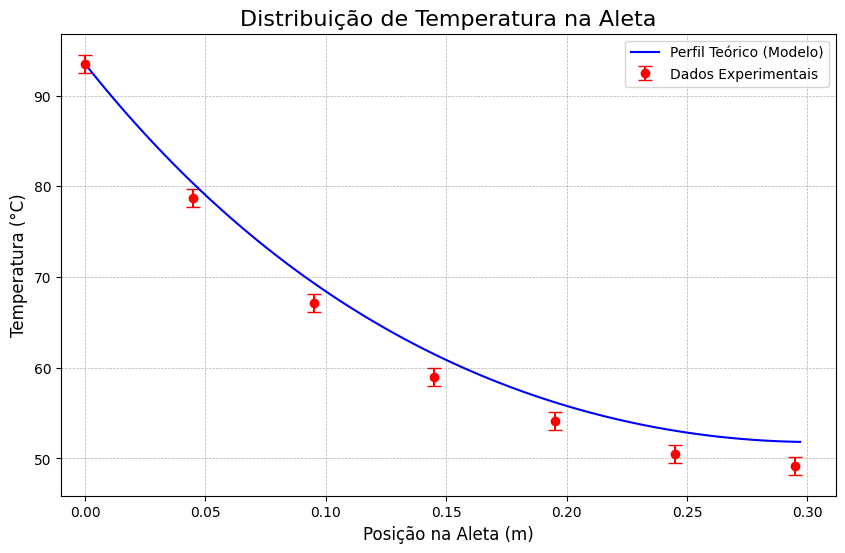

In [ ]:
# --- Bloco Principal de Execução ---

# 1. Encontrar o valor convergido de 'h' e os parâmetros associados
h_final, m_final, q_aleta_final = calcular_h_iterativo(dados_aleta, constantes)

# 2. Calcular as métricas de desempenho da aleta
efetividade, eficiencia = calcular_desempenho_aleta(h_final, q_aleta_final, dados_aleta)

# 3. Calcular o perfil teórico de temperatura para o gráfico
perfil_teorico = calcular_perfil_teorico(h_final, m_final, dados_aleta, constantes)

# --- Apresentação dos Resultados ---
print("\n" + "="*50)
print("      RESULTADOS FINAIS PARA O RELATÓRIO")
print("="*50)

print("\n--- Coeficiente de Transferência de Calor ---")
print(f"h (Convergido) = {h_final:.5f} W/(m^2·K)")

print("\n--- Grandezas da Aleta (para Tabela 3) ---")
print(f"Taxa de Transferência de Calor (q_aleta) = {q_aleta_final:.5f} W")
print(f"Efetividade (ε) = {efetividade:.5f}")
print(f"Eficiência (η) = {eficiencia:.5f}")
print("="*50)

# 4. Gerar e exibir o gráfico
plotar_grafico(dados_aleta, perfil_teorico)